In [1]:
from google.colab import drive
import os
drive.mount('/content/drive')
print(os.listdir('/content/drive/MyDrive/NIDS'))

Mounted at /content/drive
['UNSW_NB15_training-set.csv', 'UNSW_NB15_testing-set.csv', 'UNSW_NB15_training-set.gsheet']


x_train: (175341, 42)
y_train: (175341,)
x_test: (82332, 42)
y_test: (82332,)
['proto', 'service', 'state']
39
Before preprocessing:
x : (175341, 42)
x1: (82332, 42)

After preprocessing:
x_processed : (175341, 194)
x1_processed: (82332, 194)


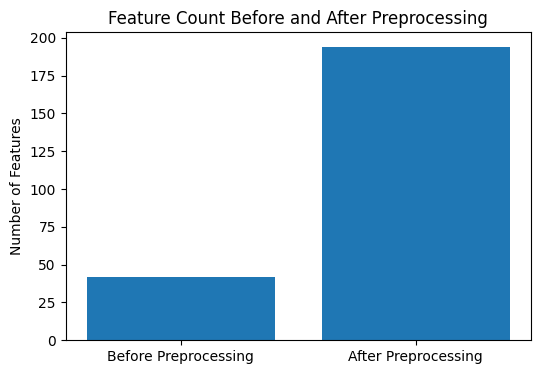

In [ ]:
import pandas as pd
train_path = '/content/drive/MyDrive/NIDS/UNSW_NB15_training-set.csv'           #loaded the content for training
test_path = '/content/drive/MyDrive/NIDS/UNSW_NB15_testing-set.csv'             #loaded for the test
train=pd.read_csv(train_path)                                                   #reading the file
test=pd.read_csv(test_path)                                                     #reading the test file
#print("training shape",train.shape)
#print("testing shape",test.shape)                                                 #checking the shape of the file
#print(train.head())
#print(train.columns.tolist())
#print(train.isnull().sum())                                                      #calculated the no. of missing values
#print(train['label'].value_counts())                                             #calculated the no. of labels here

##print(train.dtypes)                                                             #no. of dtypes

#categorical_cols = train.select_dtypes(include=['object']).columns
#print(categorical_cols)

#for col in categorical_cols:
    #print(f"\n{col}:")
    #print(train[col].value_counts().head(20))

x=train.drop(columns=['id','attack_cat','label'])                                #drop the column for avoiding the data leakage from train
y=train['label']


x1=test.drop(columns=['id','attack_cat','label'])                                 #drop the column for avoiding the data leakage from test
y1=test['label']


print('x_train:',x.shape)
print('y_train:',y.shape)
print('x_test:',x1.shape)
print('y_test:',y1.shape)

categorical_cols=x.select_dtypes(include=['object']).columns.tolist()
numerical_cols=x.select_dtypes(exclude=['object']).columns.tolist()
print(categorical_cols)
print(len(numerical_cols))

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_cols = ['proto', 'service', 'state']

preprocessor = ColumnTransformer(
    transformers=[
        ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
)

x_processed = preprocessor.fit_transform(x)
x1_processed = preprocessor.transform(x1)


print("Before preprocessing:")
print("x :", x.shape)
print("x1:", x1.shape)

print("\nAfter preprocessing:")
print("x_processed :", x_processed.shape)
print("x1_processed:", x1_processed.shape)

import matplotlib.pyplot as plt

features_before = x.shape[1]
features_after = x_processed.shape[1]

plt.figure(figsize=(6,4))
plt.bar(
    ['Before Preprocessing', 'After Preprocessing'],
    [features_before, features_after]
)

plt.ylabel('Number of Features')
plt.title('Feature Count Before and After Preprocessing')
plt.show()

from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier(random_state=42)
model.fit(x_processed,y)


y_pred=model.predict(x1_processed)

from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y1, y_pred)

print("Accuracy:", accuracy)
print("\nClassification Report:")
print(classification_report(y1, y_pred))

import numpy as np

random_indices = np.random.choice(len(y1), 10, replace=False)

for i in random_indices:
    print(
        f"Index {i}: Actual = {y1.iloc[i]}, Predicted = {y_pred[i]}"
    )

[[27755  9245]
 [ 1964 43368]]


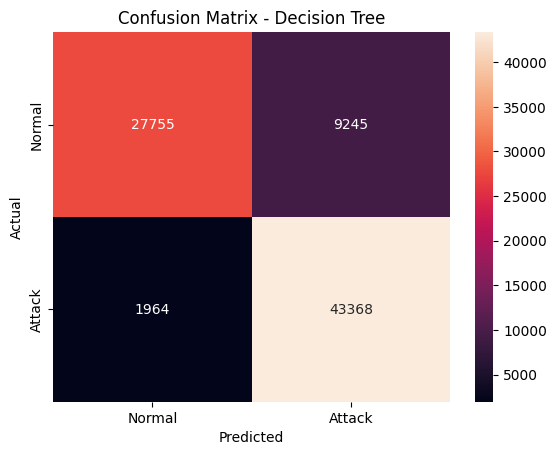

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y1, y_pred)

print(cm)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Normal', 'Attack'],
    yticklabels=['Normal', 'Attack']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Decision Tree')
plt.show()